# JEM - Coupling between jcm and veros
This notebook demonstrates a JAX-ESM (JEM) example using JAX-GCM (JCM), Slab Ocean Model, and Slab Land Model.
Please also see the adapter functions in `jem/components/Veros.py` and `jem/components/JCM.py`.

## Import Packages

In [1]:
import os, sys
from pathlib import Path

# or `export PYTHONPATH=/path/to/jax-esm/root/directory`
sys.path.append( (Path(os.getcwd()) / ".." ).resolve())

In [2]:
import jax
jax.config.update("jax_enable_x64", False) 
import jax.numpy as jnp
import jcm
from jcm.geometry import Geometry
import jax_datetime as jdt

from jem.tool_scripts.generate_jcm_forcing_and_topography_files import (
    generate_jcm_forcing_and_topography_files,
)
from jem.components import JCM, Veros, SlabLandModel
from jem.mapping import IdentityRegridder
from jem.mapping import BasicMapper
from jem.base.coupler import Coupler
import jem.utils.tree_tools as tree_tools

## Configurations

In [3]:
start_datetime = jdt.to_datetime("2000-01-01")
coupling_timestep = jdt.to_timedelta(1, "day")
output_dir = Path("output/JCM_VEROS_SLM").resolve()

output_dir.mkdir(exist_ok=True, parents=True)
one_second = jdt.to_timedelta(1, "second")
terrain_file = Path("funky_earth_add_cap.nc")

## Create Components

### Create Veros

First need to remove `acc.*.nc` files, otherwise veros complains.

In [4]:
import glob
import os
files = glob.glob("acc.*.nc")
for f in files:
    print(f"Deleting: {f}")
    os.remove(f)

In [5]:
from veros import runtime_settings
setattr(runtime_settings, "backend", "jax")
setattr(runtime_settings, "force_overwrite", True)
setattr(runtime_settings, 'linear_solver', 'scipy_jax')
setattr(runtime_settings, 'device', 'cpu')
from acc import ACCSetup
ocn_model = ACCSetup()
ocn_model.setup()
Veros.make_jem_compatible(
    ocn_model,
    coupling_timestep=coupling_timestep,
)

Veros path: /home/xtt/miniconda3/envs/jax/lib/python3.13/site-packages/veros/__init__.py
Importing core modules
 Using computational backend jax on cpu
  Kernels are compiled during first iteration, be patient
 Runtime settings are now locked

Running model setup
Initializing streamfunction method
 Solving for boundary contribution by island 0
 Solving for boundary contribution by island 1
 Solving for boundary contribution by island 2
 Solving for boundary contribution by island 3
 Solving for boundary contribution by island 4
 Solving for boundary contribution by island 5
 Solving for boundary contribution by island 6
 Solving for boundary contribution by island 7
Diffusion grid factor delta_iso1 = 0.010957363360409974


### Create JCM

In [6]:
atm_model = jcm.model.Model(
    start_date=start_datetime,
    geometry=Geometry.from_file(terrain_file),
)

JCM.make_jem_compatible(
    atm_model,
    coupling_timestep=coupling_timestep,
    land_model_active=True,
)

### Create Land model

In [7]:
lnd_model = SlabLandModel(
    start_datetime=start_datetime,
    topography_file=terrain_file,
    mask_file=terrain_file,
)

## Creating Flux and Scalar Exchange between Components

In [8]:
# Creating regridders and mapping
def veros_to_jcm_regridder(arr):
    return jnp.pad(arr, ((0, 0), (4, 4)), constant_values=150)
def jcm_to_veros_regridder(arr):
    return arr[:, 4:-4]
mapper = BasicMapper()
mapper.add_mapping(
    source = ("atm", "derived.total_heat_flux"),
    target = ("ocn", "forcing.total_heat_flux"),
    regridder = jcm_to_veros_regridder,
)
mapper.add_mapping(
    source = ("atm", "derived.physics.surface_flux.u0"),
    target = ("ocn", "forcing.wind_x"),
    regridder = jcm_to_veros_regridder,
)
mapper.add_mapping(
    source = ("atm", "derived.physics.surface_flux.v0"),
    target = ("ocn", "forcing.wind_y"),
    regridder = jcm_to_veros_regridder,
)
mapper.add_mapping(
    source = ("ocn", "derived.sea_surface_temperature"),
    target = ("atm", "forcing.sea_surface_temperature"),
    regridder = veros_to_jcm_regridder,
)
mapper.add_mapping(
    source = ("atm", "derived.total_heat_flux"),
    target = ("lnd", "forcing.total_heat_flux"),
)
mapper.add_mapping(
    source = ("lnd", "state.land_surface_temperature"),
    target = ("atm", "forcing.stl_am"),
)

## Create Coupled Model

In [9]:
model = Coupler(
    components=dict(
        atm=atm_model,
        ocn=ocn_model,
        lnd=lnd_model,
    ),
    mappers=dict(mapper=mapper),
)

print("Model info: ") 
tree_tools.print_tree(model.get_info(), root="Model")

Checking `initialize` => `typing.Callable[[], typing.Any]`
Checking `generate_step_function` => `typing.Callable[[], typing.Callable[[typing.Any, float], tuple[typing.Any, typing.Any]]]`
Checking `predictions_to_xarray` => `typing.Callable[[typing.Any], xarray.core.dataset.Dataset]`
Checking `get_info` => `typing.Callable[[], typing.Dict]`
Checking `initialize` => `typing.Callable[[], typing.Any]`
Checking `generate_step_function` => `typing.Callable[[], typing.Callable[[typing.Any, float], tuple[typing.Any, typing.Any]]]`
Checking `predictions_to_xarray` => `typing.Callable[[typing.Any], xarray.core.dataset.Dataset]`
Checking `get_info` => `typing.Callable[[], typing.Dict]`
Checking `initialize` => `typing.Callable[[], typing.Any]`
Checking `generate_step_function` => `typing.Callable[[], typing.Callable[[typing.Any, float], tuple[typing.Any, typing.Any]]]`
Checking `predictions_to_xarray` => `typing.Callable[[typing.Any], xarray.core.dataset.Dataset]`
Checking `get_info` => `typing.C

## Run Coupled Model

In [10]:
simulation_interval = jdt.to_timedelta(20, "day")
initial_state, final_state, predictions = model.run(
    workflow=["mapper", "atm", "ocn", "lnd"],
    iterations = int(simulation_interval / coupling_timestep),
    jitted=True,
)

Initializing land masks from domain...
Total land grid count: 1289.0
No boundary file specified. Using idealized land climatology.
Heat capacity range: 3.46e-02 - 3.46e-02
Dissipation coefficient range: 0.000 - 1.000
Initial land temperature range: 280.65 - 298.15 K
Flattened workflow:  mapper, atm, ocn, lnd
Doing: lnd.state.land_surface_temperature -> atm.forcing.stl_am
Doing: ocn.derived.sea_surface_temperature -> atm.forcing.sea_surface_temperature
Doing: atm.derived.total_heat_flux -> lnd.forcing.total_heat_flux
Notice: Mapping for ocn -> lnd does not exist.
Doing: atm.derived.physics.surface_flux.v0 -> ocn.forcing.wind_y
Notice: Mapping for lnd -> ocn does not exist.
Doing: lnd.state.land_surface_temperature -> atm.forcing.stl_am
Doing: ocn.derived.sea_surface_temperature -> atm.forcing.sea_surface_temperature
Doing: atm.derived.total_heat_flux -> lnd.forcing.total_heat_flux
Notice: Mapping for ocn -> lnd does not exist.
Doing: atm.derived.physics.surface_flux.v0 -> ocn.forcing.wi

Simulation:   0%|          | 0/20 [00:00<?, ?it/s]

## Output into NetCDF

In [11]:
output_dict = model.predictions_to_xarray(predictions)
for component_name, ds in output_dict.items():
    output_file = output_dir / f"{component_name:s}.nc"
    print("Output file: ", str(output_file))
    ds.to_netcdf(output_file, engine="netcdf4")

nodal_shape =  (8, 96, 48)
data.keys =  ['u_wind', 'v_wind', 'temperature', 'specific_humidity', 'geopotential', 'normalized_surface_pressure', 'shortwave_rad.qcloud', 'shortwave_rad.fsol', 'shortwave_rad.rsds', 'shortwave_rad.rsns', 'shortwave_rad.ozone', 'shortwave_rad.ozupp', 'shortwave_rad.zenit', 'shortwave_rad.stratz', 'shortwave_rad.gse', 'shortwave_rad.icltop', 'shortwave_rad.cloudc', 'shortwave_rad.cloudstr', 'shortwave_rad.ftop', 'shortwave_rad.dfabs', 'shortwave_rad.compute_shortwave', 'longwave_rad.dfabs', 'longwave_rad.ftop', 'convection.se', 'convection.iptop', 'convection.cbmf', 'convection.qdif', 'convection.precnv', 'mod_radcon.ablco2', 'mod_radcon.alb_l', 'mod_radcon.alb_s', 'mod_radcon.albsfc', 'mod_radcon.snowc', 'humidity.rh', 'humidity.qsat', 'condensation.precls', 'condensation.dtlsc', 'condensation.dqlsc', 'surface_flux.rlds', 'surface_flux.rlns', 'surface_flux.tsfc', 'surface_flux.tskin', 'surface_flux.u0', 'surface_flux.v0', 'surface_flux.t0', 'date.tyear', 'd

# Visualization

In [12]:
import matplotlib.pyplot as plt

## Atmosphere

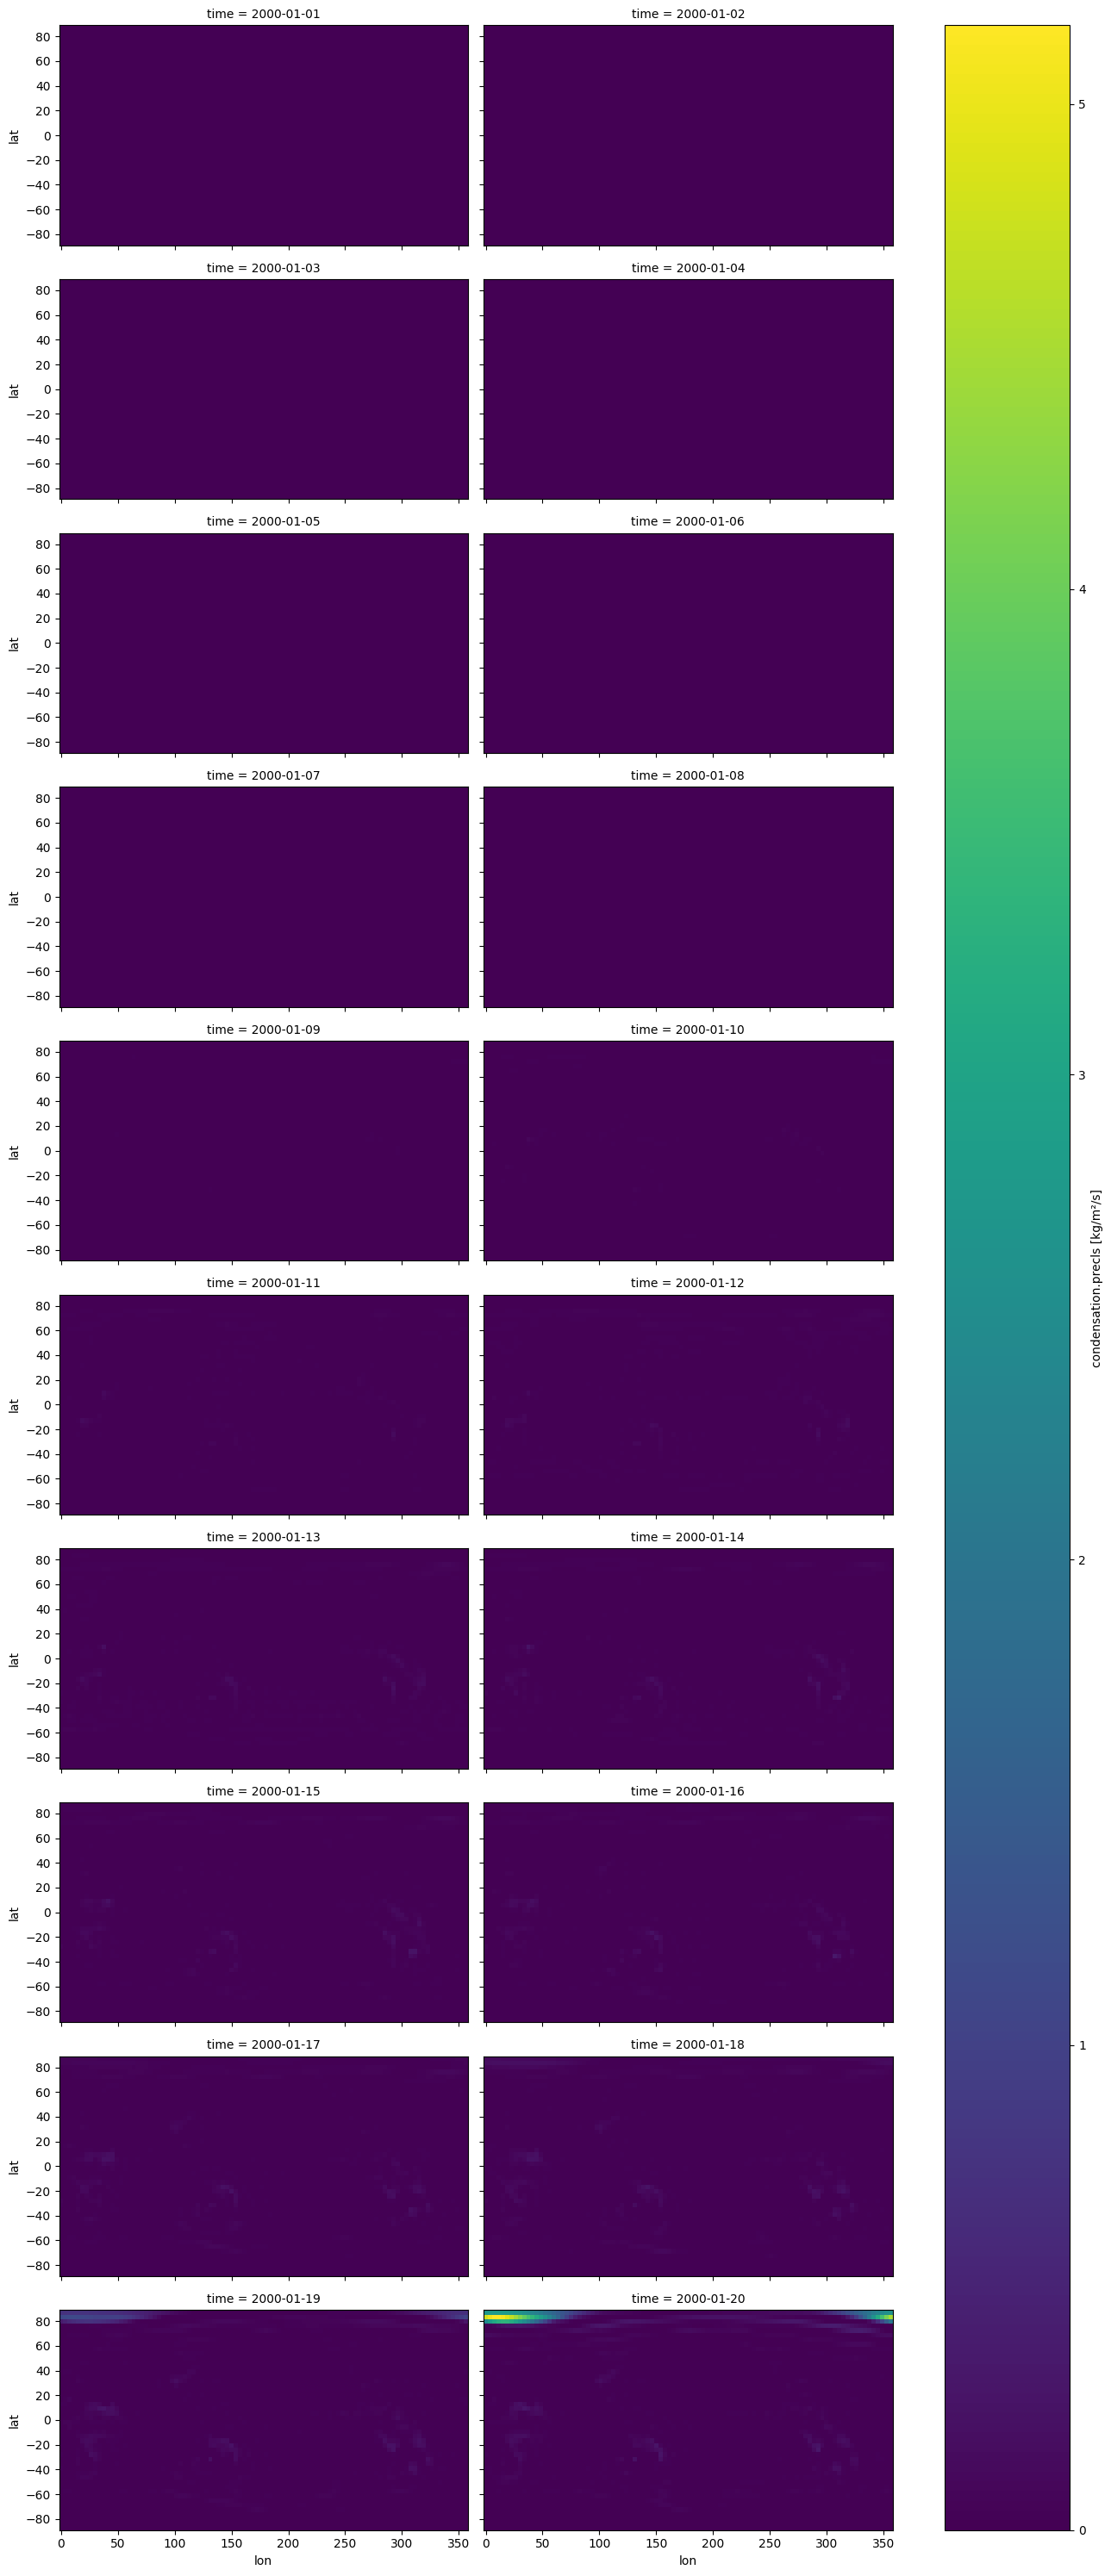

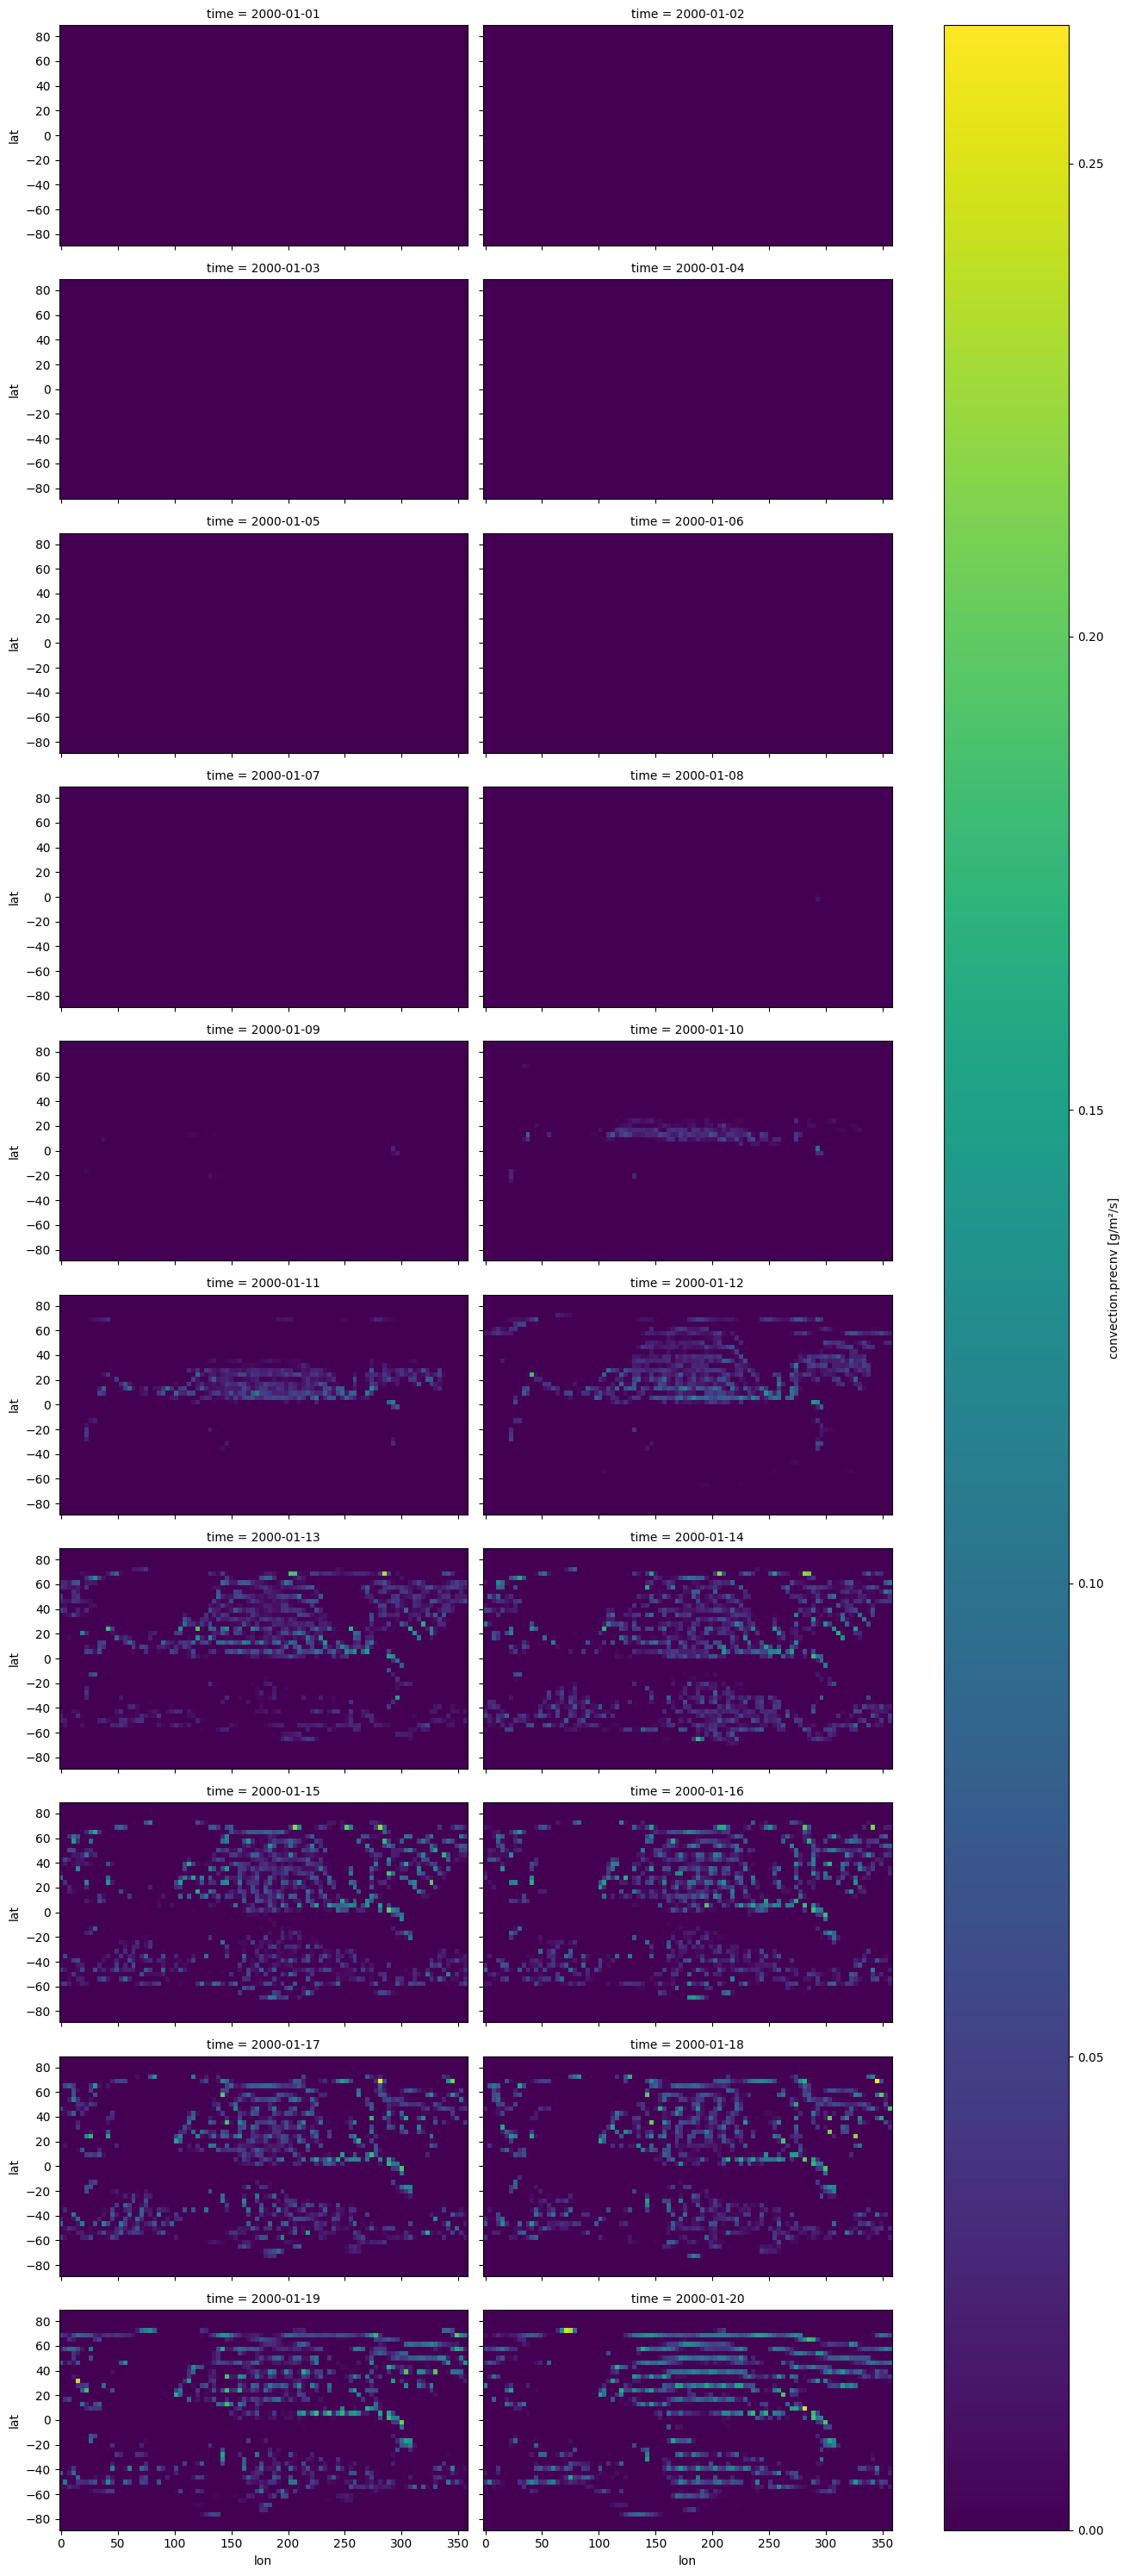

In [13]:
ds = output_dict["atm"]
ds['condensation.precls'].plot(x='lon', y='lat', col='time', col_wrap=2, aspect=2)
ds['convection.precnv'].plot(x='lon', y='lat', col='time', col_wrap=2, aspect=2)

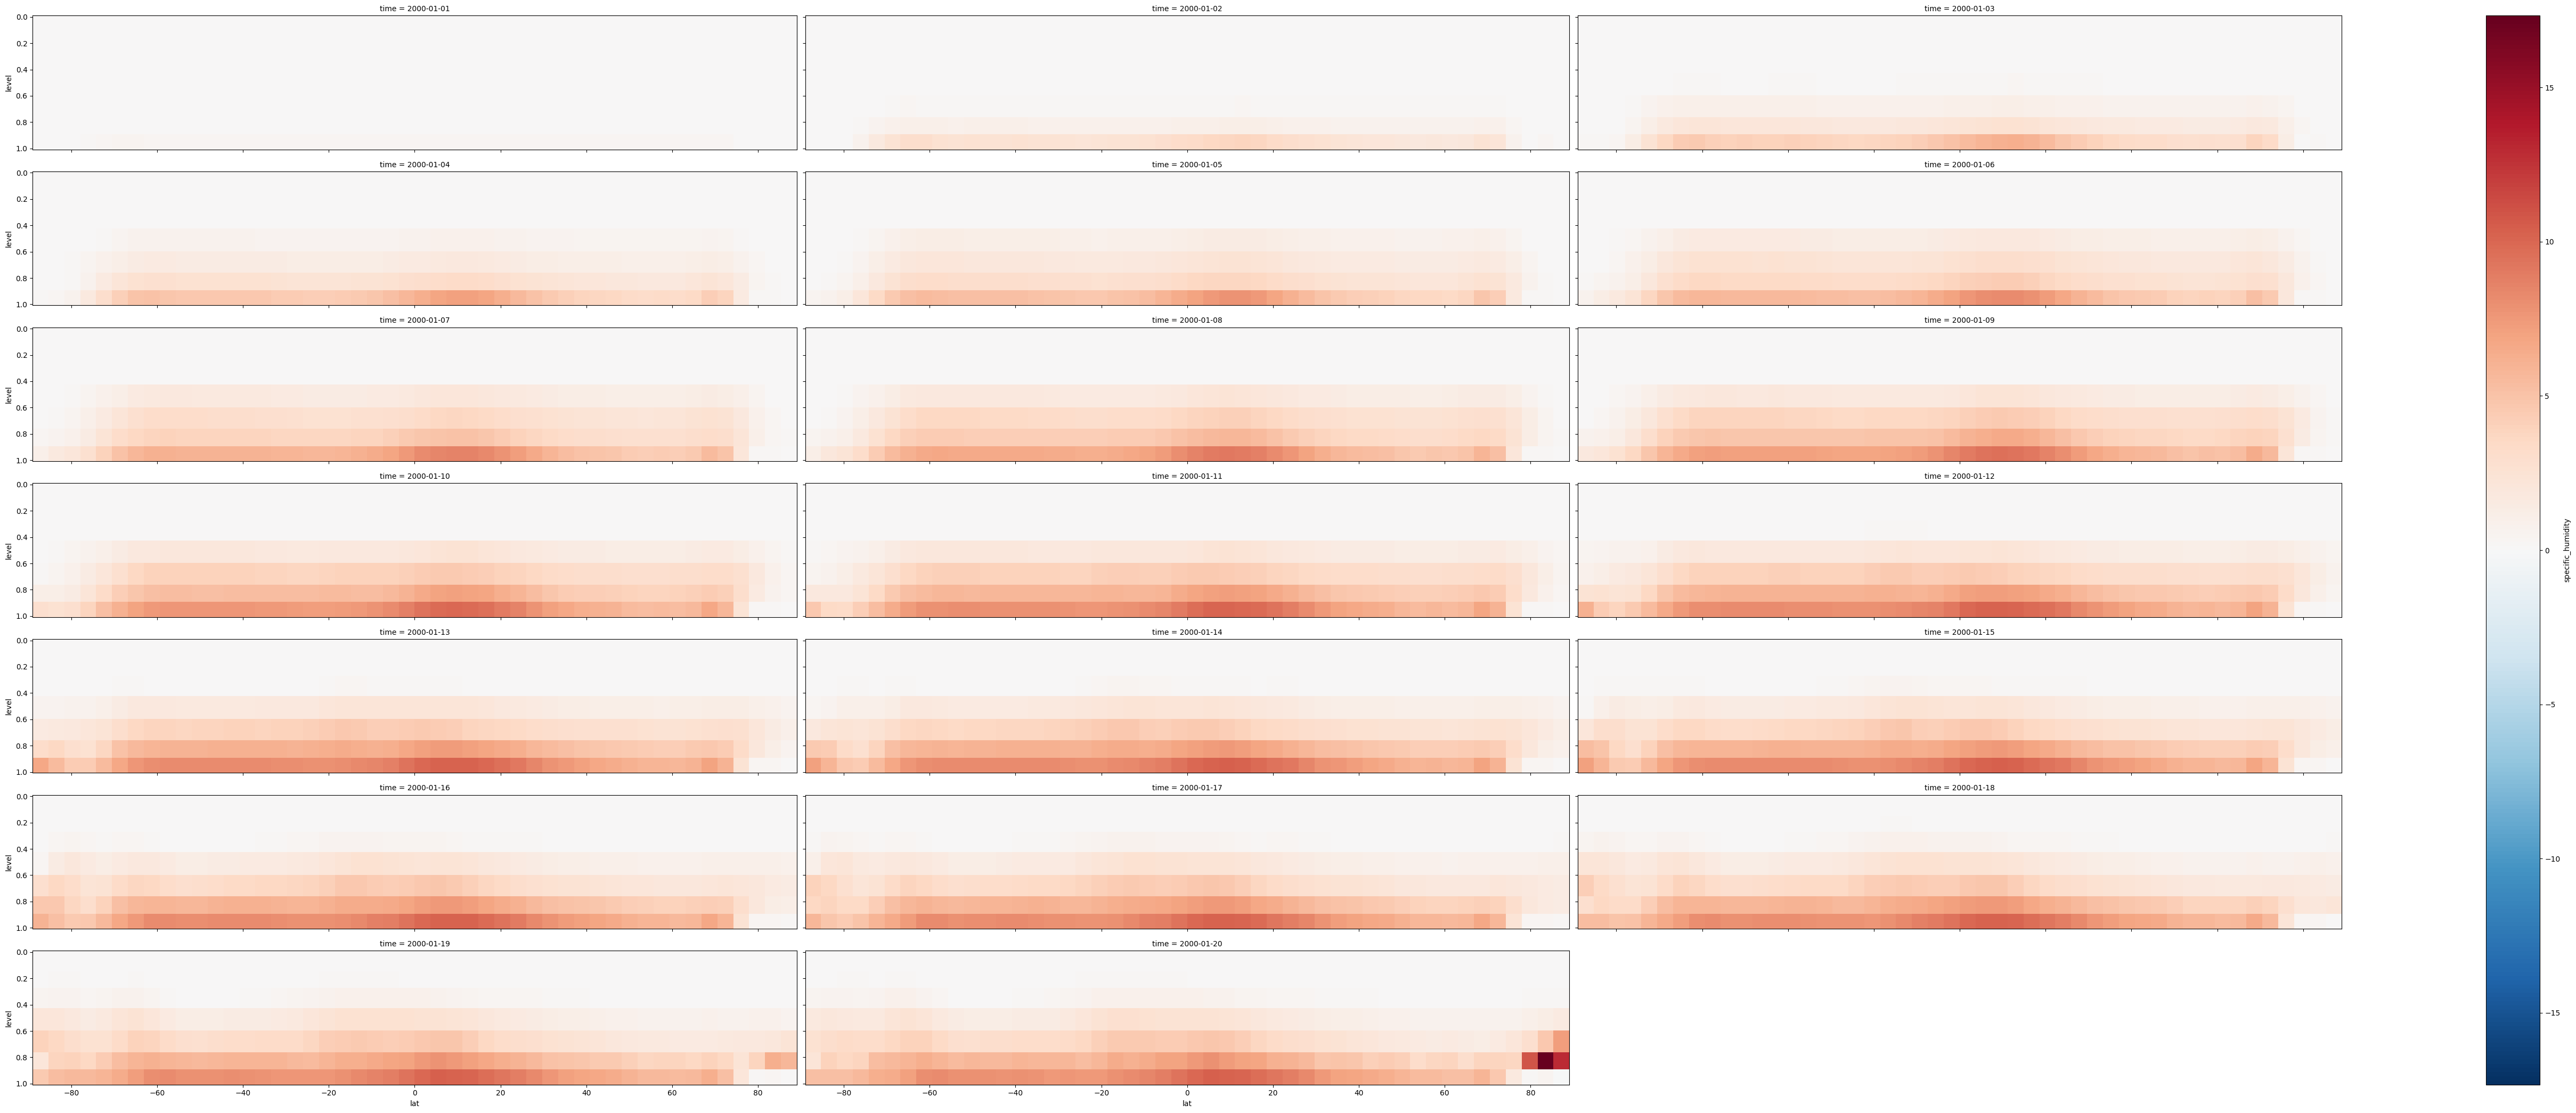

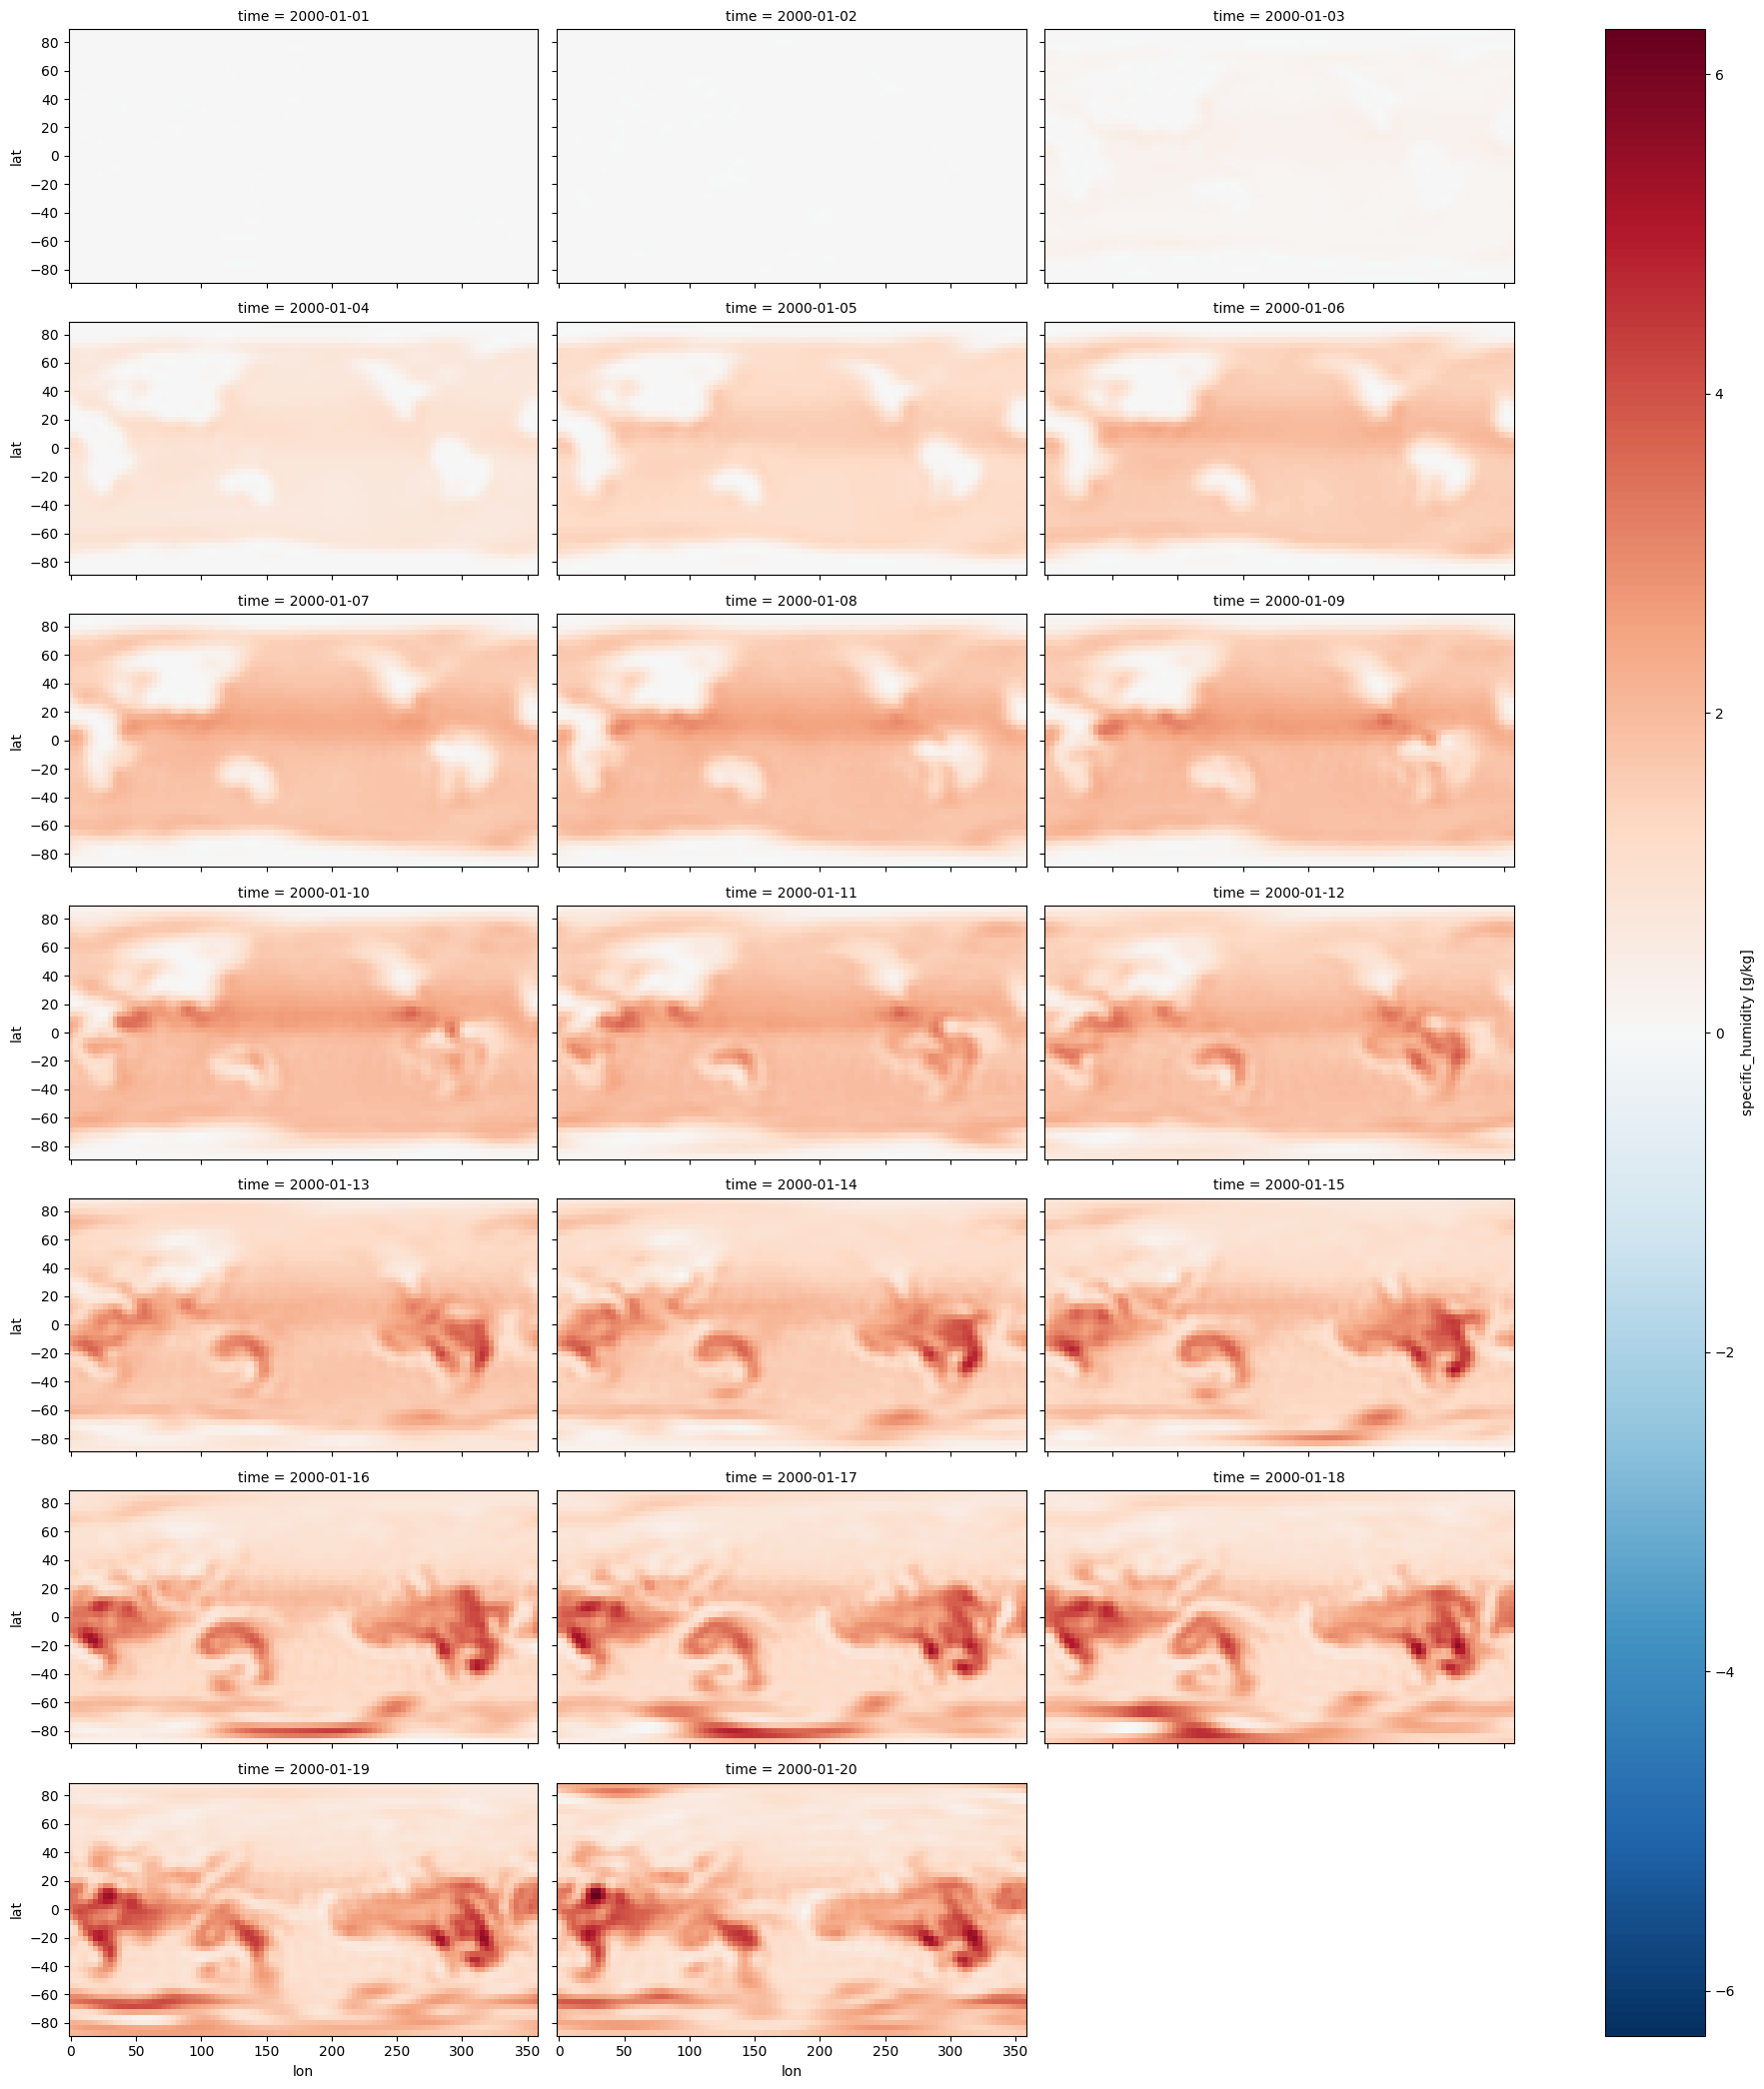

In [14]:
ds['specific_humidity'].mean('lon').plot(x='lat', y='level', col='time', col_wrap=3, aspect=6, yincrease=False)
ds['specific_humidity'].isel(level=3).plot(x='lon', y='lat', col='time', col_wrap=3, aspect=2)

## Ocean

In [15]:
ds = output_dict["ocn"]
print(str(ds))

<xarray.Dataset> Size: 3MB
Dimensions:                  (time: 20, longitude: 96, latitude: 40)
Dimensions without coordinates: time, longitude, latitude
Data variables:
    sea_surface_temperature  (time, longitude, latitude) float64 614kB ...
    surface_air_temperature  (time, longitude, latitude) float64 614kB ...
    wind_x                   (time, longitude, latitude) float64 614kB ...
    wind_y                   (time, longitude, latitude) float64 614kB ...
    total_heat_flux          (time, longitude, latitude) float64 614kB ...


Text(0.5, 0.98, 'Sea Surface Temperature [${}^\\circ \\mathrm{C}$]')

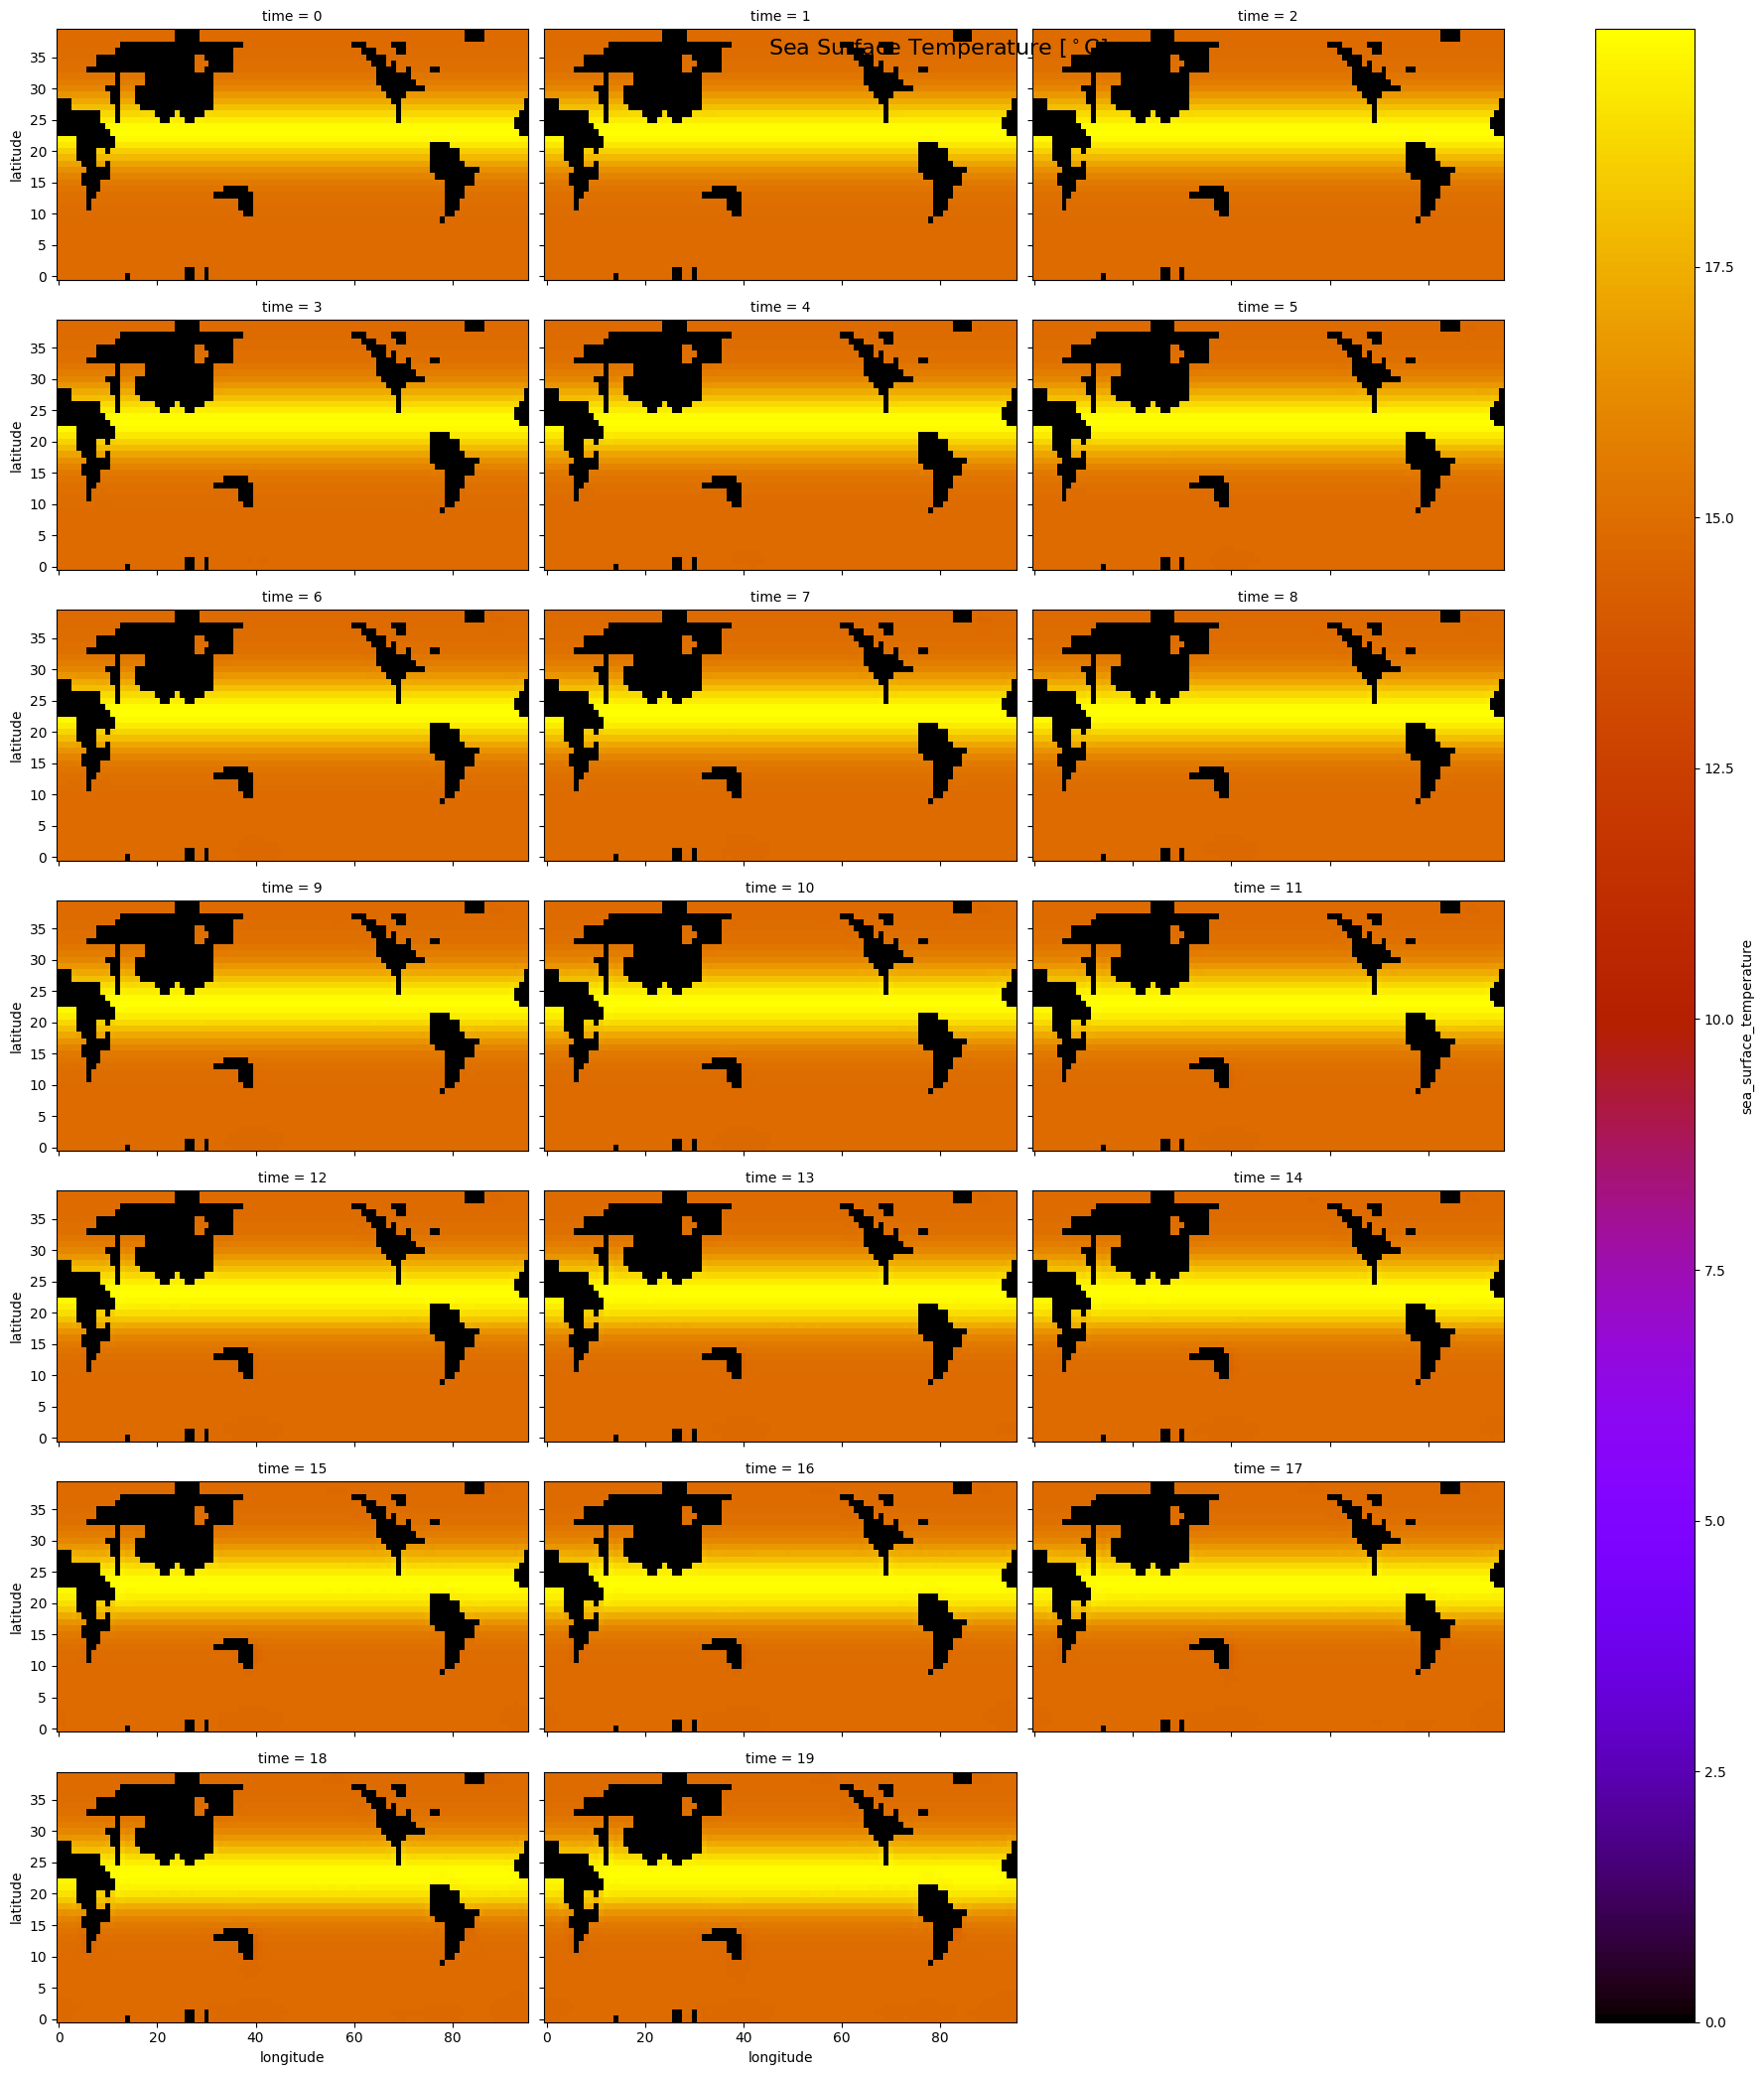

In [16]:
g = (ds['sea_surface_temperature'] - 273.15).plot(x='longitude', y='latitude', col='time', col_wrap=3, aspect=2, cmap="gnuplot")
g.fig.suptitle("Sea Surface Temperature [${}^\\circ \\mathrm{C}$]", fontsize=16)

## Land

In [17]:
ds = output_dict["lnd"]
print(str(ds))

<xarray.Dataset> Size: 3MB
Dimensions:                   (time: 20, longitude: 96, latitude: 48)
Coordinates:
  * time                      (time) float64 160B 24.0 48.0 72.0 ... 456.0 480.0
    latitude2D                (longitude, latitude) float64 37kB ...
    longitude2D               (longitude, latitude) float64 37kB ...
Dimensions without coordinates: longitude, latitude
Data variables:
    land_surface_temperature  (time, longitude, latitude) float64 737kB ...
    snowd                     (time, longitude, latitude) float64 737kB ...
    soilw                     (time, longitude, latitude) float64 737kB ...
    total_heat_flux           (time, longitude, latitude) float64 737kB ...
Attributes:
    description:  SPEEDY-based slab land surface model output
    depth_soil:   1.0 m
    depth_lice:   5.0 m
    tdland:       3456000.0 days


Text(0.5, 1.02, 'Land Surface Temperature [${}^\\circ \\mathrm{C}$]')

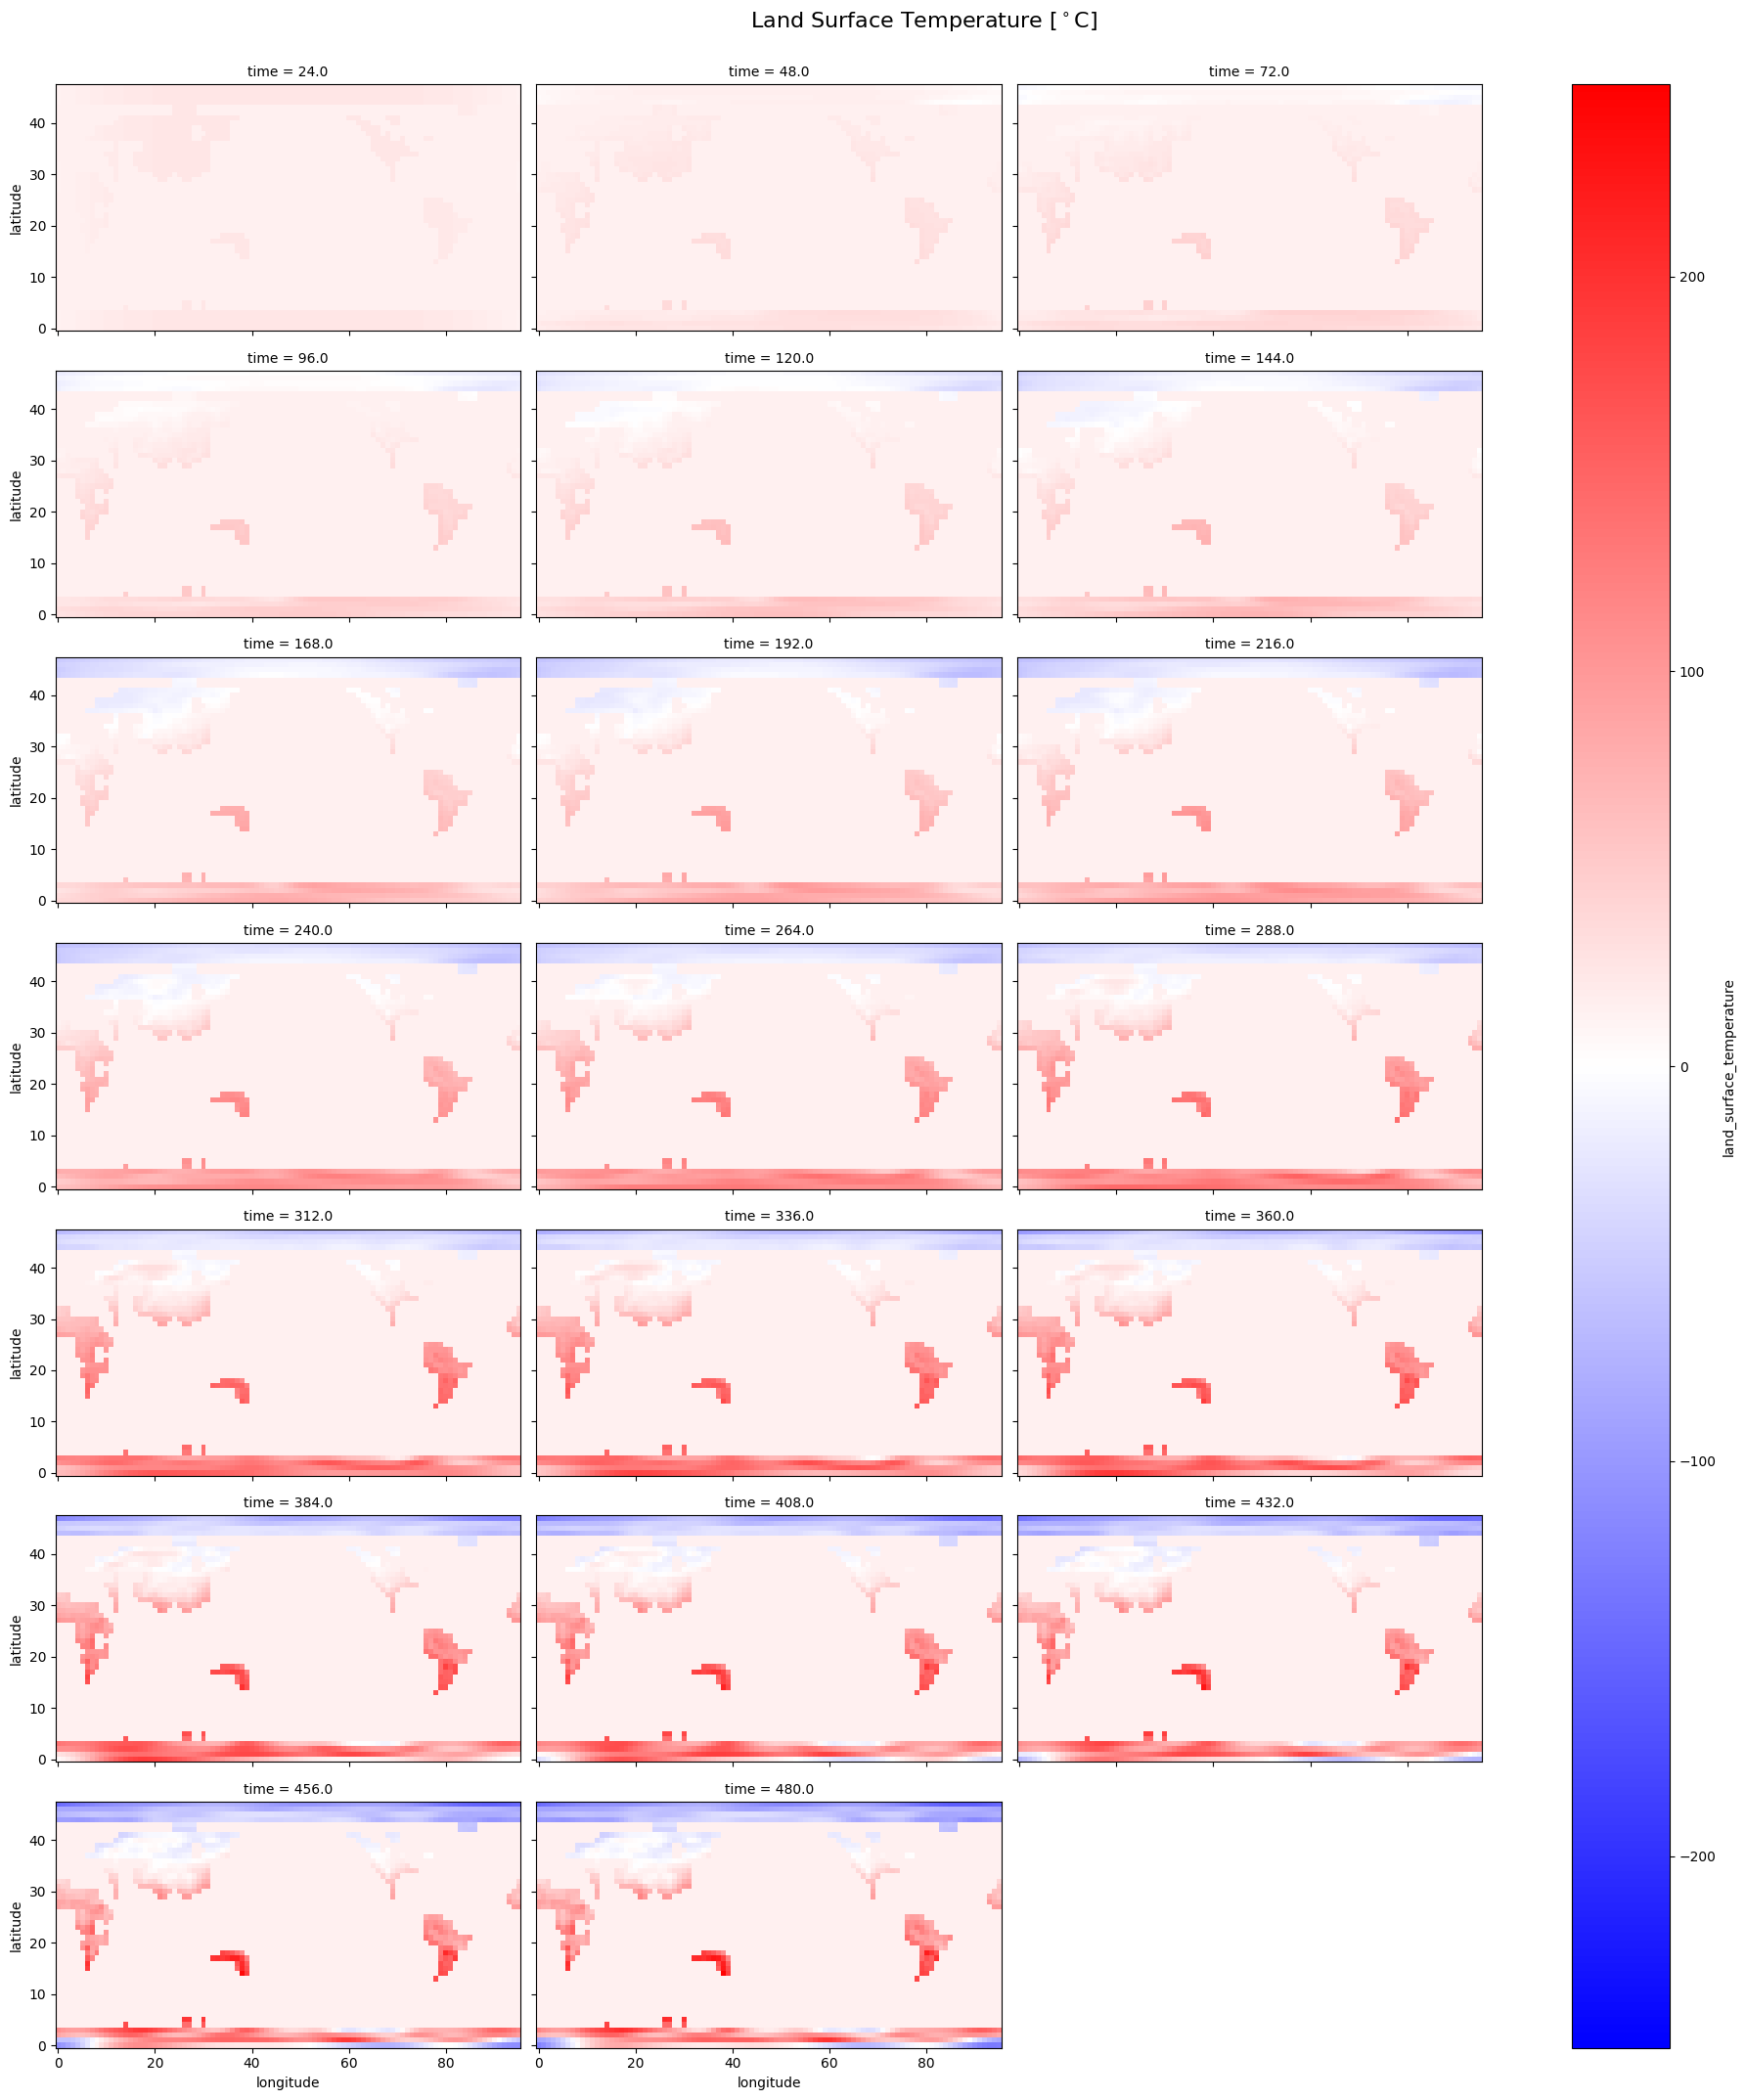

In [18]:
g = (ds['land_surface_temperature'] - 273.15).plot(x='longitude', y='latitude', col='time', col_wrap=3, aspect=2, cmap="bwr", center=0)
g.fig.suptitle("Land Surface Temperature [${}^\\circ \\mathrm{C}$]", fontsize=16, y=1.02)